In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner ,solve, Rational, simplify
print("x")

x


In [2]:
# Restricciones (1-(p1+p2+p3)=0), E y V
p1 = 0.3
m1 = 0.1
m2 = 0.05
m3 = 0.2
v1 = 0.2
v2 = 0.1
v3 = 0.3
cv12 = 0.05
cv13 = 0.10 
cv23 = 0.10

In [3]:
cov = np.array([
    [v1,    cv12, cv13],
    [cv12,  v2,   cv23],
    [cv13,  cv23, v3  ]
])
print(np.linalg.eigvals(cov)) #Definida positiva

[0.40280302 0.13925809 0.0579389 ]


In [4]:
p1, p2, E, V = symbols('p1 p2 E V')

p3 = 1 - p1 - p2

E_resta = m1*p1 + m2*p2 + m3*p3
pol2 = E - E_resta

V_resta = (
    v1*p1**2 + v2*p2**2 + v3*p3**2 +
    2*cv12*p1*p2 +
    2*cv13*p1*p3 +
    2*cv23*p2*p3
)

pol3 = V - V_resta

In [5]:
G = groebner([pol2, pol3], p1, p2, E, V, order='lex')

In [6]:
list(G)

[10.0*E + 1.0*p1 + 1.5*p2 - 2.0,
 70.5882352941176*E**2 + 14.1176470588235*E*p2 - 18.8235294117647*E - 2.35294117647059*V + 1.0*p2**2 - 2.35294117647059*p2 + 1.64705882352941]

In [7]:
E_reducido = -(1.0*p1 + 1.5*p2 - 2.0)/10

In [8]:
eq1 = 10.0*E + 1.0*p1 + 1.5*p2 - 2.0
eq2 = 70.5882352941176*E**2 + 14.1176470588235*E*p2 - 18.8235294117647*E - 2.35294117647059*V + 1.0*p2**2 - 2.35294117647059*p2 + 1.64705882352941

p1_expr = solve(eq1, p1)[0]
eq2_sub = simplify(eq2.subs(p1, p1_expr))

# 3) resolver para p2
sol_p2 = solve(eq2_sub, p2)

print("Soluciones para p2:")
print(sol_p2)

Soluciones para p2:
[-7.05882352941175*E - 1.47058823529412e-14*sqrt(-9.60000000000007e+28*E**2 + 1.02400000000002e+28*E + 1.088e+28*V - 1.216e+27) + 1.17647058823529, -7.05882352941175*E + 1.47058823529412e-14*sqrt(-9.60000000000007e+28*E**2 + 1.02400000000002e+28*E + 1.088e+28*V - 1.216e+27) + 1.17647058823529]


Vemos que nos da 2 ecuaciones, una de ella seguramente no sea valida.
Ahora hay 2 caminos, fijar E o fijar V, vamos a ver las 2 posibilidades<br>
Si fijamos E, entonces nos queda un polinomio en funcion de V, el objetivo sera minimizar esta V, <br>
Al reves para V, si dijamos V nuestro objetivo es maximizar E<br>

In [9]:
#Por ejemplo, fijemos E = 3.4 (inflacion de españa, tiene que vencer la inflacion) + 5%
E, V = sp.symbols('E V', real=True)

E_valor = 0.2

p1 = -7.05882352941175*E - 1.47058823529412e-14*sp.sqrt(-9.60000000000007e+28*E**2 + 1.02400000000002e+28*E + 1.088e+28*V - 1.216e+27) + 1.17647058823529

p2 = -7.05882352941175*E + 1.47058823529412e-14*sp.sqrt(-9.60000000000007e+28*E**2 + 1.02400000000002e+28*E + 1.088e+28*V - 1.216e+27) + 1.17647058823529

In [10]:
p1_E = p1.subs(E, E_valor)
p2_E = p2.subs(E, E_valor)
print(p1_E)
print(p2_E)

-1.47058823529412e-14*sqrt(1.088e+28*V - 3.00799999999999e+27) - 0.23529411764706
1.47058823529412e-14*sqrt(1.088e+28*V - 3.00799999999999e+27) - 0.23529411764706


In [11]:
df = sp.diff(p1_E, V)
print(df)

-80000000000000.1/sqrt(1.088e+28*V - 3.00799999999999e+27)


<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1.47058823529412e-14*sqrt(1.088e+28*V - 3.00799999999999e+27) - 0.23529411764706


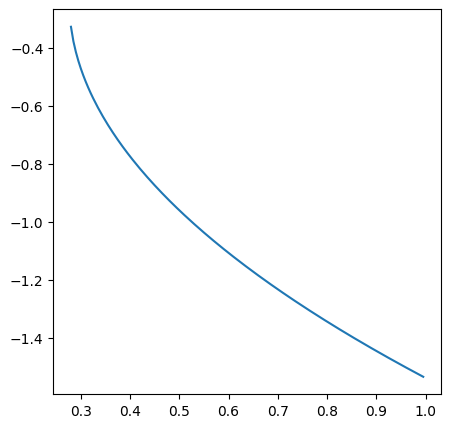

In [24]:
f = -1.47058823529412e-14*sp.sqrt(1.088e+28*V - 3.00799999999999e+27) - 0.23529411764706
valores = np.arange(0,1, 0.005)
f_np = sp.lambdify(V, f, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np(valores))
plt.show()

<lambdifygenerated-12>:2: RuntimeWarning: invalid value encountered in sqrt
  return 1.47058823529412e-14*sqrt(1.088e+28*V - 3.00799999999999e+27) - 0.23529411764706


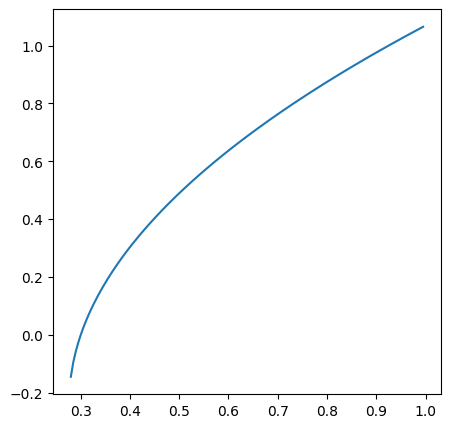

nan


In [25]:
f2 = 1.47058823529412e-14*sp.sqrt(1.088e+28*V - 3.00799999999999e+27) - 0.23529411764706
f_np2 = sp.lambdify(V, f2, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np2(valores))
plt.show()